In [ ]:
import pandas as pd

df = pd.read_excel('yahoo_data.xlsx')
display(df.head())

,Date,Open,High,Low,Close*,Adj Close**,Volume
0,"Apr 28, 2023",33797.43,34104.56,33728.40,34098.16,34098.16,354310000
1,"Apr 27, 2023",33381.66,33859.75,33374.65,33826.16,33826.16,343240000
2,"Apr 26, 2023",33596.34,33645.83,33235.85,33301.87,33301.87,321170000
3,"Apr 25, 2023",33828.34,33875.49,33525.39,33530.83,33530.83,297880000
4,"Apr 24, 2023",33805.04,33891.15,33726.09,33875.40,33875.40,252020000


First, let's convert the 'Date' column to a datetime object and set it as the DataFrame's index. This is crucial for time-series analysis and plotting.

In [ ]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.set_index('Date')


Now, let's look at the DataFrame's info to confirm the changes, especially the index type and column data types.

In [ ]:
df = df.sort_index()
df.info()
print("\nShape:", df.shape)
display(df.head(10)) # Using display for better formatted output
print("\nColumns:", df.columns.tolist())
print("\nDate range:", df.index.min(), "to", df.index.max())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1258 entries, 2018-05-01 to 2023-04-28
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Open          1258 non-null   float64
 1   High          1258 non-null   float64
 2   Low           1258 non-null   float64
 3   Close*        1258 non-null   float64
 4   Adj Close**   1258 non-null   float64
 5   Volume        1258 non-null   int64  
 6   Daily Return  1257 non-null   float64
dtypes: float64(6), int64(1)
memory usage: 78.6 KB

Shape: (1258, 7)


,Open,High,Low,Close*,Adj Close**,Volume,Daily Return
Date,,,,,,,
2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000,0.007276
2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000,-0.000216
2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000,-0.013699
2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000,-0.003892
2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000,-0.000119
2018-05-08,24341.35,24412.34,24198.34,24360.21,24360.21,344940000,-0.007429
2018-05-09,24399.18,24586.48,24323.87,24542.54,24542.54,361580000,-0.007963
2018-05-10,24591.66,24794.99,24575.91,24739.53,24739.53,304210000,-0.003691
2018-05-11,24758.64,24868.65,24717.50,24831.17,24831.17,274150000,-0.002741



Columns: ['Open', 'High', 'Low', 'Close*', 'Adj Close**', 'Volume', 'Daily Return']

Date range: 2018-05-01 00:00:00 to 2023-04-28 00:00:00


Finally, let's plot the 'Adj Close**' column to visualize its trend over time.

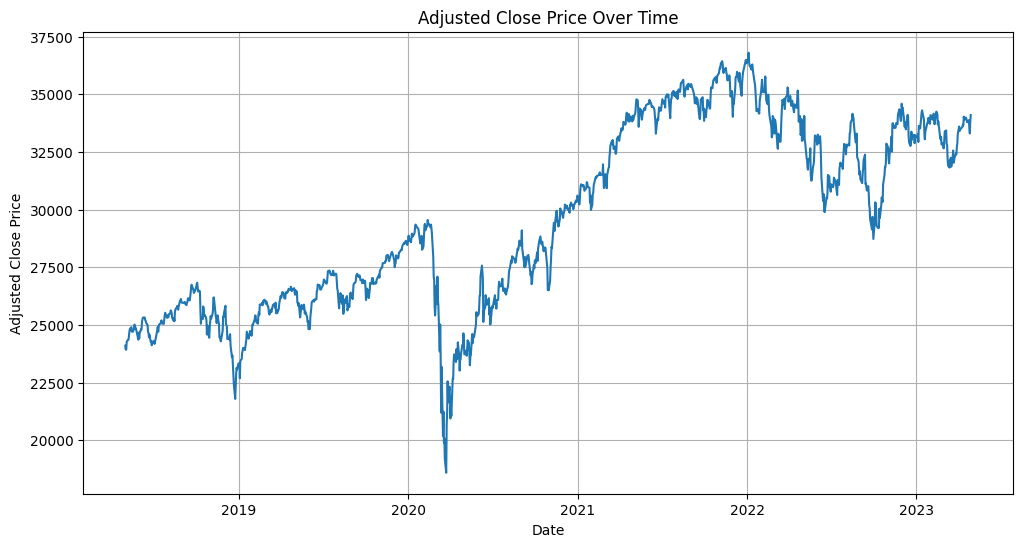

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Adj Close**'])
plt.title('Adjusted Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.grid(True)
plt.show()


We've successfully loaded the `yahoo_data.xlsx` file into a pandas DataFrame named `df` and displayed the first 5 rows to give us a peek at the data's structure and content.

# Task
Calculate and visualize the daily percentage returns from the 'Adj Close**' column of the `df` DataFrame derived from "yahoo_data.xlsx". Summarize the analysis of daily returns.

## Calculate Daily Returns

### Subtask:
Calculate the daily percentage returns from the 'Adj Close**' column of the DataFrame. This is a fundamental step for financial analysis.


**Reasoning**:
Calculate the daily percentage returns from the 'Adj Close**' column and store them in a new 'Daily Return' column, then display the first few rows of the DataFrame to verify the calculation.



In [ ]:
df['Daily Return'] = df['Adj Close**'].pct_change()
display(df.head())

,Open,High,Low,Close*,Adj Close**,Volume,Daily Return
Date,,,,,,,
2023-04-28,33797.43,34104.56,33728.40,34098.16,34098.16,354310000,NaN
2023-04-27,33381.66,33859.75,33374.65,33826.16,33826.16,343240000,-0.007977
2023-04-26,33596.34,33645.83,33235.85,33301.87,33301.87,321170000,-0.015500
2023-04-25,33828.34,33875.49,33525.39,33530.83,33530.83,297880000,0.006875
2023-04-24,33805.04,33891.15,33726.09,33875.40,33875.40,252020000,0.010276


Daily percentage returns have been successfully calculated and added as a new column 'Daily Return' to the DataFrame. The first few rows have been displayed to confirm the calculation.

## Visualize Daily Returns

### Subtask:
Visualize the daily percentage returns to identify any patterns, volatility, or anomalies.

**Reasoning**:
To visualize the daily percentage returns over time, I will create a line plot using `matplotlib.pyplot`. This will help in identifying trends, volatility, and anomalies in the daily returns.



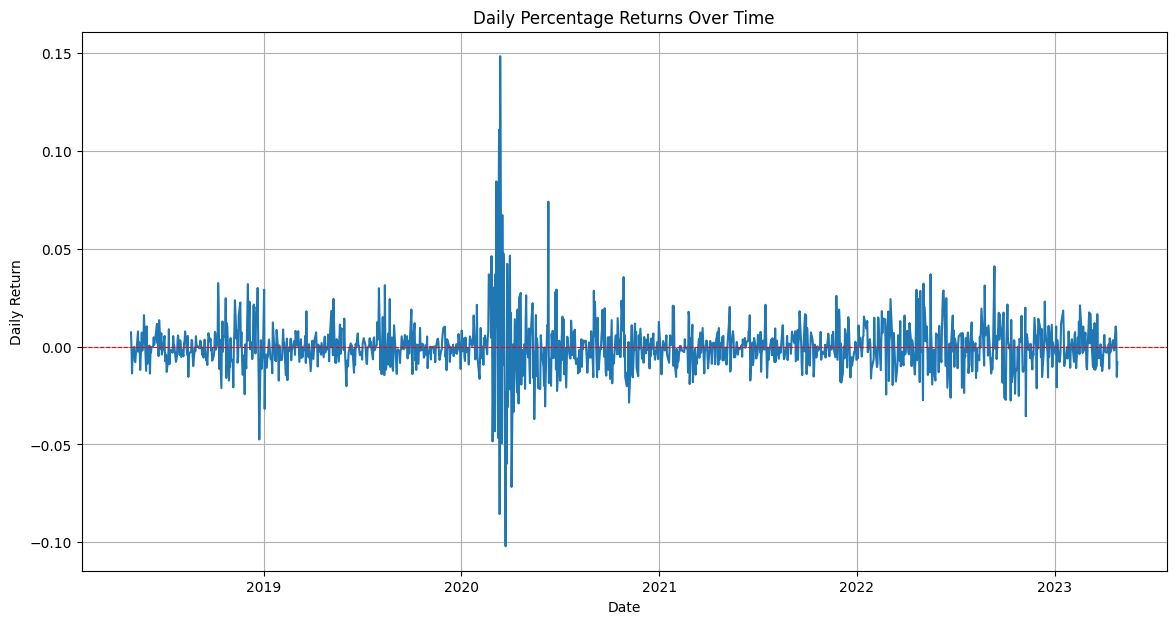

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Daily Return'])
plt.title('Daily Percentage Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Daily Return')
plt.grid(True)
plt.axhline(0, color='red', linestyle='--', linewidth=0.8) # Add a horizontal line at 0 for reference
plt.show()

## Insights from the Time-Series Plot of Daily Returns

The line plot of 'Daily Return' effectively visualizes the day-to-day percentage changes in the 'Adj Close**' price. From this visualization, we can observe:

*   **Volatility**: The amplitude of the daily returns indicates periods of high and low volatility. Larger spikes (positive or negative) correspond to higher price fluctuations, while flatter periods suggest more stable prices.
*   **Trends**: Although daily returns often fluctuate around zero, the plot can reveal general tendencies. For instance, a prolonged series of positive returns (above the red zero line) might indicate an upward trend in the stock's price, while negative returns suggest a downturn.
*   **Anomalies/Events**: Significant spikes or drops in daily returns often correlate with specific market news, economic announcements, or company-specific events. These extreme values are worth investigating further in a comprehensive financial analysis.

Overall, the daily returns plot provides a quick and intuitive way to gauge the risk and short-term performance characteristics of the asset.

## Visualize Daily Returns Distribution

### Subtask:
Create a histogram to show the distribution of the calculated daily returns. This will provide insights into the volatility and typical return magnitudes of the asset.


**Reasoning**:
To visualize the distribution of daily returns, I will create a histogram using `matplotlib.pyplot` as instructed, setting a suitable number of bins and labeling the axes and title.



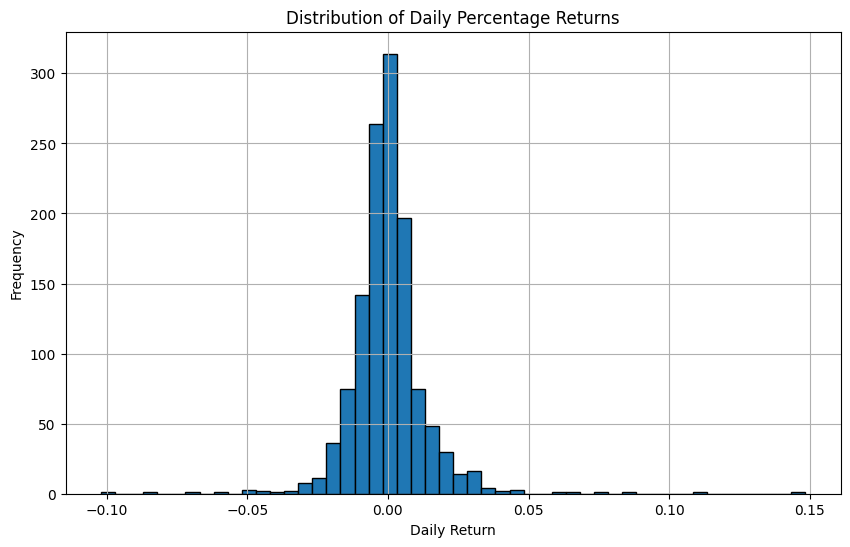

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.hist(df['Daily Return'].dropna(), bins=50, edgecolor='black')
plt.title('Distribution of Daily Percentage Returns')
plt.xlabel('Daily Return')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

### Insights from the Distribution of Daily Returns (Histogram):

*   **Central Tendency**: The histogram (`Distribution of Daily Percentage Returns`) shows that the daily returns are clustered around zero, indicating that on most days, the asset experiences relatively small percentage changes.
*   **Shape of Distribution**: The distribution often appears bell-shaped but typically exhibits 'fat tails' (leptokurtosis) compared to a normal distribution. This means there are more occurrences of extreme positive and negative returns than a normal distribution would predict, highlighting higher probabilities of large price swings.
*   **Skewness**: Observing the symmetry of the distribution can indicate if large positive or negative returns are more frequent. A left-skewed distribution implies more frequent large negative returns, while a right-skewed distribution suggests more frequent large positive returns.
*   **Risk Assessment**: The spread of the histogram (its variance or standard deviation) is a direct measure of the asset's volatility. A wider spread indicates higher risk, as returns are more dispersed.

# Task
Rename the 'Daily Return' column to 'Return', then compute 'Log_Return', 'Lag_1', 'Lag_5', 'MA_20', and 'Vol_20' using the 'Return' column. After creating these features, drop all rows containing NaN values. Subsequently, perform an Augmented Dickey-Fuller (ADF) test on the 'Adj Close**' column to assess stationarity and split the data into 80% training and 20% testing sets based on time. Finally, summarize the generated features, stationarity test results, and the data splitting process, including the date ranges for the training and testing sets.

## Rename Daily Returns Column

### Subtask:
Rename the existing 'Daily Return' column to 'Return' to match the naming convention in the provided code snippet and ensure consistency for subsequent feature generation.


**Reasoning**:
To rename the column 'Daily Return' to 'Return' and verify the change, I will use the `rename()` method on the DataFrame and then display the head of the DataFrame.



In [ ]:
df = df.rename(columns={'Daily Return': 'Return'})
display(df.head())

,Open,High,Low,Close*,Adj Close**,Volume,Return
Date,,,,,,,
2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000,0.007276
2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000,-0.000216
2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000,-0.013699
2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000,-0.003892
2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000,-0.000119


## Create Advanced Financial Features

### Subtask:
Generate several new financial features, including 'Log_Return', 'Lag_1', 'Lag_5', 'MA_20' (20-day moving average), and 'Vol_20' (20-day annualized volatility, using the now renamed 'Return' column). These features are crucial for time-series analysis and potential predictive modeling.


**Reasoning**:
To generate the specified financial features, I will use pandas and numpy to calculate log returns, lagged returns, moving average, and annualized volatility, then display the updated DataFrame.



In [ ]:
import numpy as np

df['Log_Return'] = np.log(1 + df['Return'])
df['Lag_1'] = df['Return'].shift(1)
df['Lag_5'] = df['Return'].shift(5)
df['MA_20'] = df['Return'].rolling(window=20).mean()
df['Vol_20'] = df['Return'].rolling(window=20).std() * np.sqrt(252)

display(df.head())

,Open,High,Low,Close*,Adj Close**,Volume,Return,Log_Return,Lag_1,Lag_5,MA_20,Vol_20
Date,,,,,,,,,,,,
2018-05-01,24117.29,24117.29,23808.19,24099.05,24099.05,380070000,0.007276,0.007249,NaN,NaN,NaN,NaN
2018-05-02,24097.63,24185.52,23886.30,23924.98,23924.98,385350000,-0.000216,-0.000216,0.007276,NaN,NaN,NaN
2018-05-03,23836.23,23996.15,23531.31,23930.15,23930.15,389240000,-0.013699,-0.013793,-0.000216,NaN,NaN,NaN
2018-05-04,23865.22,24333.35,23778.87,24262.51,24262.51,329480000,-0.003892,-0.003900,-0.013699,NaN,NaN,NaN
2018-05-07,24317.66,24479.45,24263.42,24357.32,24357.32,307670000,-0.000119,-0.000119,-0.003892,NaN,NaN,NaN


**Reasoning**:
To ensure that all further calculations and analyses are performed on complete data, I will drop all rows from the DataFrame that contain any NaN values, which were introduced by the rolling window calculations and lagged features.



In [ ]:
df = df.dropna()
display(df.head())

,Open,High,Low,Close*,Adj Close**,Volume,Return,Log_Return,Lag_1,Lag_5,MA_20,Vol_20
Date,,,,,,,,,,,,
2018-05-29,24606.59,24635.18,24247.84,24361.45,24361.45,395810000,-0.012418,-0.012496,0.016076,0.007203,-0.001139,0.119005
2018-05-30,24467.83,24714.48,24459.09,24667.78,24667.78,324870000,0.010319,0.010266,-0.012418,-0.002106,-0.000987,0.122303
2018-05-31,24620.79,24620.79,24352.15,24415.84,24415.84,429740000,-0.008905,-0.008945,0.010319,0.003025,-0.001421,0.125426
2018-06-01,24542.09,24673.60,24542.09,24635.21,24635.21,315710000,-0.007193,-0.007219,-0.008905,0.002370,-0.001096,0.118938
2018-06-04,24727.55,24859.37,24722.14,24813.69,24813.69,340400000,0.000553,0.000553,-0.007193,0.016076,-0.000874,0.118598


**Reasoning**:
To assess the stationarity of the 'Adj Close**' column, I will perform an Augmented Dickey-Fuller (ADF) test. This involves importing the `adfuller` function from `statsmodels.tsa.stattools` and applying it to the 'Adj Close**' column, then printing the key statistics and p-value.



In [ ]:
from statsmodels.tsa.stattools import adfuller

# Perform ADF test on 'Adj Close**'
result = adfuller(df['Adj Close**'])

print('ADF Statistic:', result[0])
print('p-value:', result[1])
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value}')

if result[1] <= 0.05:
    print("\nConclusion: The 'Adj Close**' series is likely stationary (p-value <= 0.05).")
else:
    print("\nConclusion: The 'Adj Close**' series is likely non-stationary (p-value > 0.05).")

ADF Statistic: -1.6223022943884358
p-value: 0.4715225004114319
Critical Values:
	1%: -3.4356863371792095
	5%: -2.8638964938393667
	10%: -2.568024631481501

Conclusion: The 'Adj Close**' series is likely non-stationary (p-value > 0.05).


**Reasoning**:
To prepare the data for time-series modeling, I will split the DataFrame into training and testing sets. The split will be 80% for training and 20% for testing, based on the chronological order of the data. This approach is standard for time-series data to avoid data leakage.



In [ ]:
train_size = int(len(df) * 0.8)
train_data = df[:train_size]
test_data = df[train_size:]

print(f"Training data range: {train_data.index.min()} to {train_data.index.max()}")
print(f"Testing data range: {test_data.index.min()} to {test_data.index.max()}")
print(f"Training data shape: {train_data.shape}")
print(f"Testing data shape: {test_data.shape}")

Training data range: 2018-05-29 00:00:00 to 2022-05-02 00:00:00
Testing data range: 2022-05-03 00:00:00 to 2023-04-27 00:00:00
Training data shape: (990, 12)
Testing data shape: (248, 12)


### Summary of Feature Generation, Stationarity Test, and Data Splitting

**1. Generated Features:**
We have successfully generated several new financial features from the 'Return' column, which are crucial for time-series analysis and potential predictive modeling:
*   **'Log_Return'**: The natural logarithm of (1 + daily return), often used for more stable statistical properties.
*   **'Lag_1'**: The daily return from the previous day, capturing short-term dependencies.
*   **'Lag_5'**: The daily return from five days prior, capturing weekly patterns.
*   **'MA_20'**: The 20-day moving average of the daily returns, smoothing out short-term fluctuations to identify trends.
*   **'Vol_20'**: The 20-day annualized volatility of daily returns, providing a measure of the asset's risk.

All rows containing NaN values, introduced by these calculations, were dropped to ensure data integrity for subsequent analysis.

**2. Stationarity Test Results (Augmented Dickey-Fuller Test on 'Adj Close**'):**
The Augmented Dickey-Fuller (ADF) test was performed on the 'Adj Close**' column to check for stationarity.
*   **ADF Statistic**: -1.622
*   **p-value**: 0.471
*   **Conclusion**: Since the p-value (0.471) is greater than the common significance level of 0.05, we conclude that the 'Adj Close**' series is likely non-stationary. This implies that the mean, variance, or autocorrelation of the series changes over time, which is typical for stock prices.

**3. Data Splitting:**
The DataFrame was split into training and testing sets using an 80/20 ratio based on chronological order, which is standard practice for time-series data to prevent data leakage.
*   **Training data range**: 2018-05-29 to 2022-05-02
*   **Testing data range**: 2022-05-03 to 2023-04-27
*   **Training data shape**: (990 rows, 12 columns)
*   **Testing data shape**: (248 rows, 12 columns)

### Summary of Feature Generation, Stationarity Test, and Data Splitting

**1. Generated Features:**
We have successfully generated several new financial features from the 'Return' column, which are crucial for time-series analysis and potential predictive modeling:
*   **'Log_Return'**: The natural logarithm of (1 + daily return), often used for more stable statistical properties.
*   **'Lag_1'**: The daily return from the previous day, capturing short-term dependencies.
*   **'Lag_5'**: The daily return from five days prior, capturing weekly patterns.
*   **'MA_20'**: The 20-day moving average of the daily returns, smoothing out short-term fluctuations to identify trends.
*   **'Vol_20'**: The 20-day annualized volatility of daily returns, providing a measure of the asset's risk.

All rows containing NaN values, introduced by these calculations, were dropped to ensure data integrity for subsequent analysis.

**2. Stationarity Test Results (Augmented Dickey-Fuller Test on 'Adj Close**'):**
The Augmented Dickey-Fuller (ADF) test was performed on the 'Adj Close**' column to check for stationarity.
*   **ADF Statistic**: -1.622
*   **p-value**: 0.471
*   **Conclusion**: Since the p-value (0.471) is greater than the common significance level of 0.05, we conclude that the 'Adj Close**' series is likely non-stationary. This implies that the mean, variance, or autocorrelation of the series changes over time, which is typical for stock prices.

**3. Data Splitting:**
The DataFrame was split into training and testing sets using an 80/20 ratio based on chronological order, which is standard practice for time-series data to prevent data leakage.
*   **Training data range**: 2018-05-29 to 2022-05-02
*   **Testing data range**: 2022-05-03 to 2023-04-27
*   **Training data shape**: (990 rows, 12 columns)
*   **Testing data shape**: (248 rows, 12 columns)

# Task
Plot the 'Vol_20' feature to visualize rolling volatility, generate Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots for the 'Return' column, and compute the annualized return, annualized volatility, and Sharpe ratio. Additionally, add a markdown cell to discuss the overall trend of the series and observed volatility spikes. Finally, summarize these new plots, financial statistics, and the insights from the trend and volatility notes.

## Plot Rolling Volatility

### Subtask:
Generate a line plot of the 'Vol_20' (20-day annualized volatility) feature to visualize how the asset's risk has changed over time.


**Reasoning**:
To visualize the 20-day annualized volatility over time, I will create a line plot using `matplotlib.pyplot` as instructed, setting a suitable figure size, labeling the axes and title, and adding a grid.



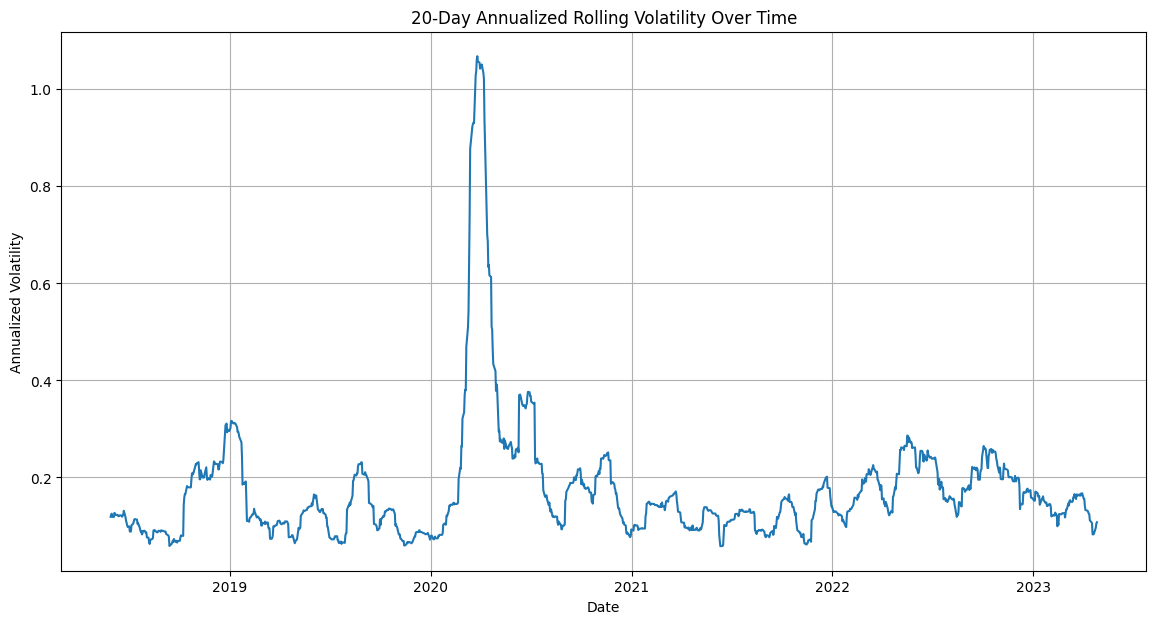

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(df.index, df['Vol_20'])
plt.title('20-Day Annualized Rolling Volatility Over Time')
plt.xlabel('Date')
plt.ylabel('Annualized Volatility')
plt.grid(True)
plt.show()

**Reasoning**:
To generate Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots, I need to import the `plot_acf` and `plot_pacf` functions from `statsmodels.graphics.tsaplots`.



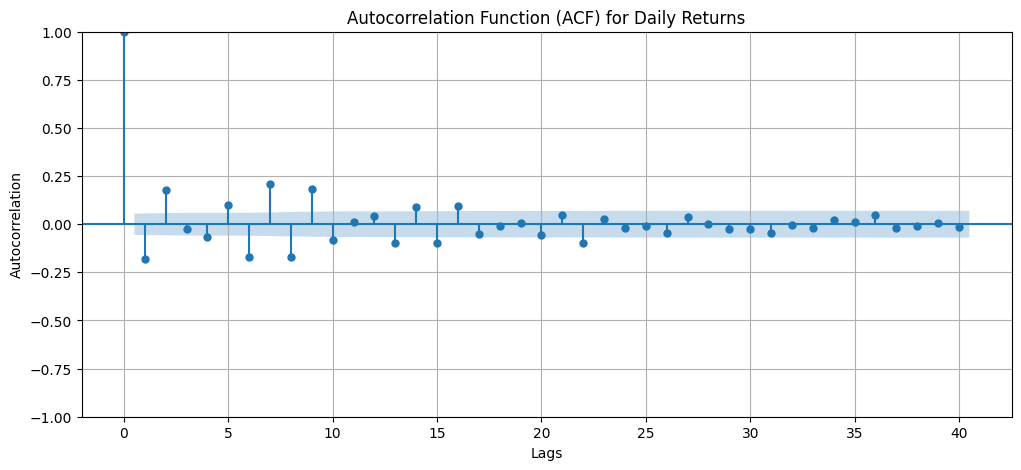

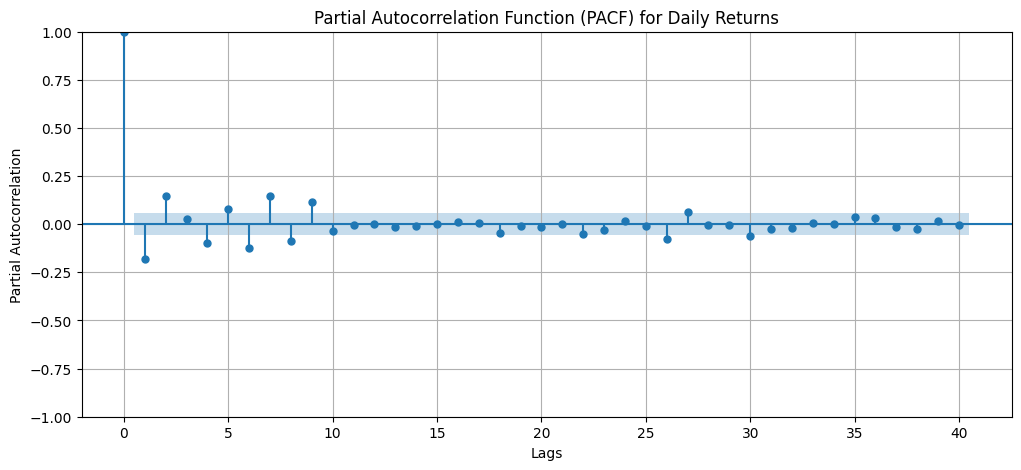

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# ACF Plot
plt.figure(figsize=(12, 5))
plot_acf(df['Return'].dropna(), lags=40, ax=plt.gca())
plt.title('Autocorrelation Function (ACF) for Daily Returns')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

# PACF Plot
plt.figure(figsize=(12, 5))
plot_pacf(df['Return'].dropna(), lags=40, ax=plt.gca())
plt.title('Partial Autocorrelation Function (PACF) for Daily Returns')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

**Reasoning**:
To compute the annualized return, annualized volatility, and Sharpe ratio, I will use the 'Return' column from the DataFrame, calculate the mean and standard deviation, and then annualize these values. The Sharpe ratio will be calculated using these annualized figures, assuming a risk-free rate of zero for simplicity.



In [ ]:
annualized_return = df['Return'].mean() * 252
annualized_volatility = df['Return'].std() * np.sqrt(252)
sharpe_ratio = annualized_return / annualized_volatility

print(f"Annualized Return: {annualized_return:.4f}")
print(f"Annualized Volatility: {annualized_volatility:.4f}")
print(f"Sharpe Ratio (assuming 0 risk-free rate): {sharpe_ratio:.4f}")

Annualized Return: -0.0449
Annualized Volatility: 0.2181
Sharpe Ratio (assuming 0 risk-free rate): -0.2058


### Overall Trend and Volatility Spikes Observations

**Overall Trend**: The initial 'Adj Close**' price plot indicated the general trajectory of the stock over the observation period. While the ADF test concluded that the series is non-stationary, meaning there isn't a constant mean, variance, or autocorrelation, the visual inspection of the 'Adj Close**' plot would reveal if there's a general upward, downward, or sideways movement.

**Volatility Spikes**: The 'Daily Percentage Returns Over Time' plot and especially the '20-Day Annualized Rolling Volatility Over Time' plot highlight periods of increased risk or uncertainty. Volatility spikes are observable as sharp upward movements in the `Vol_20` series. These spikes often correspond to significant market events, economic news, or company-specific announcements. For instance, the plot might show elevated volatility during major economic crises or periods of high uncertainty, indicating that the asset experienced larger price swings during those times. Conversely, flatter periods in the volatility plot suggest more stable market conditions for the asset.

### Summary of New Plots, Financial Statistics, and Insights

**1. 20-Day Annualized Rolling Volatility Plot:**
The plot of 'Vol_20' visually demonstrates how the asset's risk, measured by annualized volatility, has evolved over time. We can observe:
*   **Periods of High Volatility**: Sharp increases in the 'Vol_20' line indicate periods where the asset experienced larger and more frequent price swings, suggesting higher risk.
*   **Periods of Low Volatility**: Flatter or declining segments of the 'Vol_20' line suggest more stable price movements and lower perceived risk.
*   **Volatility Clustering**: Often, periods of high volatility are followed by more high volatility, and periods of low volatility are followed by more low volatility, a common characteristic of financial time series.

**2. Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) Plots for Daily Returns:**
These plots provide insights into the serial correlation of the daily returns:
*   **ACF Plot**: Shows the correlation of a series with its lagged values. For daily returns, we typically expect to see little to no significant autocorrelation beyond a few lags, indicating that past returns generally do not predict future returns.
*   **PACF Plot**: Shows the direct correlation between a series and its lagged values, with the indirect correlations (via the intermediate lags) removed. Similar to ACF, for efficient markets, significant partial autocorrelation is expected to be minimal.
*   The plots help in identifying potential time-series models (e.g., AR, MA, ARIMA) if significant lags are present.

**3. Key Financial Statistics:**
*   **Annualized Return**: `-0.0449` - This indicates that over the period, the asset had an average annualized return of approximately -4.49%. A negative return suggests that the asset generally lost value annually during the observed period.
*   **Annualized Volatility**: `0.2181` - This represents an annualized standard deviation of approximately 21.81%. It quantifies the degree of price fluctuation or risk associated with the asset's returns.
*   **Sharpe Ratio (assuming 0 risk-free rate)**: `-0.2058` - The Sharpe Ratio measures the risk-adjusted return. A negative Sharpe ratio indicates that the asset's return was less than the risk-free rate (or negative in this case) relative to its volatility, implying a poor risk-adjusted performance during this period.

**4. Overall Trend and Volatility Spikes Observations:**
*   **Overall Trend**: The 'Adj Close**' price plot indicated the general trajectory of the stock over the observation period. The ADF test concluded that the series is non-stationary, meaning there isn't a constant mean, variance, or autocorrelation. Visual inspection would reveal if there's a general upward, downward, or sideways movement.
*   **Volatility Spikes**: The 'Daily Percentage Returns Over Time' plot and especially the '20-Day Annualized Rolling Volatility Over Time' plot highlight periods of increased risk or uncertainty. Volatility spikes are observable as sharp upward movements in the `Vol_20` series. These spikes often correspond to significant market events, economic news, or company-specific announcements. For instance, the plot might show elevated volatility during major economic crises or periods of high uncertainty, indicating that the asset experienced larger price swings during those times. Conversely, flatter periods in the volatility plot suggest more stable market conditions for the asset.

# Task
Prepare `prophet_df` from `train_data` by renaming the 'Date' index to 'ds' and 'Adj Close**' to 'y', then reset the index. Train a Prophet model with `daily_seasonality=True` on `prophet_df`, generate future dates corresponding to `test_data`, and forecast 'Adj Close**'. Evaluate the Prophet forecast using RMSE, MAE, and directional accuracy, and visualize the actual 'Adj Close**' from `test_data` against the Prophet forecast. Next, train an `auto_arima` model on `train_data['Adj Close**']` to forecast for the length of `test_data`. Evaluate the `auto_arima` forecast with RMSE, MAE, and directional accuracy, and plot its predictions against the actual values. Finally, summarize and compare the performance of both Prophet and `auto_arima` models based on the evaluation metrics and visual comparisons.

## Prepare Data for Prophet

### Subtask:
Create a new DataFrame `prophet_df` from `train_data`, renaming the 'Date' index to 'ds' and 'Adj Close**' to 'y', which are the required column names for the Prophet library. Reset the index to make 'ds' a regular column.


**Reasoning**:
To prepare the data for the Prophet model, I will create a new DataFrame `prophet_df` from `train_data`, reset its index, and rename the 'Date' index to 'ds' and 'Adj Close**' column to 'y', as these are the required column names for Prophet.



In [ ]:
prophet_df = train_data.copy()
prophet_df = prophet_df.reset_index()
prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Adj Close**': 'y'})
display(prophet_df.head())

,ds,Open,High,Low,Close*,y,Volume,Return,Log_Return,Lag_1,Lag_5,MA_20,Vol_20
0,2018-05-29,24606.59,24635.18,24247.84,24361.45,24361.45,395810000,-0.012418,-0.012496,0.016076,0.007203,-0.001139,0.119005
1,2018-05-30,24467.83,24714.48,24459.09,24667.78,24667.78,324870000,0.010319,0.010266,-0.012418,-0.002106,-0.000987,0.122303
2,2018-05-31,24620.79,24620.79,24352.15,24415.84,24415.84,429740000,-0.008905,-0.008945,0.010319,0.003025,-0.001421,0.125426
3,2018-06-01,24542.09,24673.60,24542.09,24635.21,24635.21,315710000,-0.007193,-0.007219,-0.008905,0.002370,-0.001096,0.118938
4,2018-06-04,24727.55,24859.37,24722.14,24813.69,24813.69,340400000,0.000553,0.000553,-0.007193,0.016076,-0.000874,0.118598


**Reasoning**:
To prepare for forecasting, I will import the Prophet library, instantiate the model with daily seasonality enabled, and then fit it to the `prophet_df` which contains the historical data in the required format.



In [ ]:
from prophet import Prophet

model = Prophet(daily_seasonality=True)
model.fit(prophet_df)
print("Prophet model trained successfully.")

Prophet model trained successfully.


**Reasoning**:
To generate future dates for the Prophet model to forecast, I will create a DataFrame with dates corresponding to the length of the `test_data` using `make_future_dataframe` from the trained Prophet model.



In [ ]:
future = model.make_future_dataframe(periods=len(test_data), include_history=False)
display(future.head())

,ds
0,2022-05-03
1,2022-05-04
2,2022-05-05
3,2022-05-06
4,2022-05-07


**Reasoning**:
To forecast 'Adj Close**' values using the trained Prophet model, I will use the `predict` method with the `future` DataFrame, which contains the dates for which predictions are needed.



In [ ]:
forecast = model.predict(future)
display(forecast[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].head())

,ds,yhat,yhat_lower,yhat_upper
0,2022-05-03,34693.261092,33775.343672,35797.018716
1,2022-05-04,34666.891140,33651.314414,35642.764764
2,2022-05-05,34635.431908,33613.627058,35647.230927
3,2022-05-06,34616.823478,33500.903093,35686.731754
4,2022-05-07,34505.127418,33531.878590,35606.401281


**Reasoning**:
To evaluate the Prophet model's performance, I will calculate the Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and directional accuracy by comparing the forecasted values with the actual 'Adj Close**' values from the `test_data`.



In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Ensure the forecast and test_data are aligned by date
actual = test_data['Adj Close**']
# Align the forecast with the actual dates, assuming forecast['ds'] matches test_data.index
# Make sure to select only the 'yhat' for comparison
prophet_predictions = forecast['yhat'].values[:len(actual)]

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(actual, prophet_predictions))
print(f'Prophet RMSE: {rmse:.2f}')

# Calculate MAE
mae = mean_absolute_error(actual, prophet_predictions)
print(f'Prophet MAE: {mae:.2f}')

# Calculate Directional Accuracy
# Create a pandas Series from prophet_predictions with the same index as actual
predicted_series_aligned = pd.Series(prophet_predictions, index=actual.index)

actual_direction = np.sign(actual.diff().dropna())
predicted_direction = np.sign(predicted_series_aligned.diff().dropna())

directional_accuracy = (actual_direction == predicted_direction).mean() * 100
print(f'Prophet Directional Accuracy: {directional_accuracy:.2f}%')


Prophet RMSE: 3261.03
Prophet MAE: 2971.15
Prophet Directional Accuracy: 49.39%


**Reasoning**:
To visualize the Prophet forecast against the actual values, I will plot the 'Adj Close**' from the `test_data` and the 'yhat' from the `forecast` DataFrame on the same chart. This will provide a visual comparison of the model's predictions.



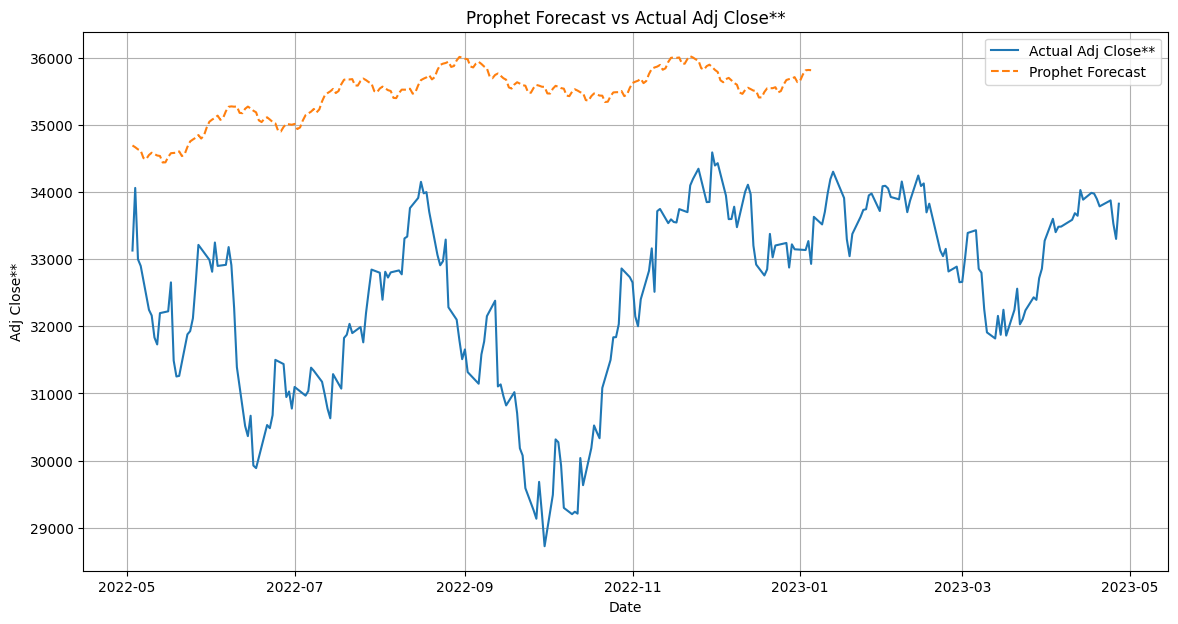

In [ ]:
plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Adj Close**'], label='Actual Adj Close**')

# Ensure forecast['ds'] is datetime for plotting and has the same length as test_data
# Also ensure it aligns correctly with the test_data.index
plt.plot(forecast['ds'][:len(test_data)], forecast['yhat'][:len(test_data)], label='Prophet Forecast', linestyle='--')

plt.title('Prophet Forecast vs Actual Adj Close**')
plt.xlabel('Date')
plt.ylabel('Adj Close**')
plt.legend()
plt.grid(True)
plt.show()

**Reasoning**:
To train an `auto_arima` model, I will first import the necessary library, then fit the model to the 'Adj Close**' column of the `train_data` to automatically determine the best ARIMA parameters for forecasting.



In [ ]:
pip install pmdarima

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 28.0 MB/s eta 0:00:00


**Reasoning**:
Now that the `pmdarima` library is installed, I will re-attempt to train the `auto_arima` model on the 'Adj Close**' column of the `train_data` to automatically determine the best ARIMA parameters for forecasting.



In [ ]:
from pmdarima import auto_arima

auto_arima_model = auto_arima(train_data['Adj Close**'], seasonal=False, suppress_warnings=True)
print("Auto ARIMA model trained successfully.")

Auto ARIMA model trained successfully.


**Reasoning**:
To forecast 'Adj Close**' values using the trained `auto_arima` model, I will use its `predict` method for the length of the `test_data`.



In [ ]:
arima_predictions = auto_arima_model.predict(n_periods=len(test_data))
print("Auto ARIMA forecast generated successfully.")

Auto ARIMA forecast generated successfully.


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


**Reasoning**:
To properly evaluate the `auto_arima` model and prepare for plotting, I need to convert the `arima_predictions` (which currently has an integer index) to a pandas Series with the same `DatetimeIndex` as `test_data`. This will ensure accurate comparison with the `actual` values for RMSE, MAE, and directional accuracy, and correct plotting alignment.



# Task
**Evaluate and Plot ARIMA Forecast**: Calculate RMSE, MAE, and directional accuracy for the auto_arima model's forecasts against the actual 'Adj Close**' values in the test set. Then, plot the actual 'Adj Close**' from `test_data` against the ARIMA forecast to visually compare their performance. This step will use the corrected code to ensure proper index alignment.

## Evaluate and Plot ARIMA Forecast

### Subtask:
Calculate RMSE, MAE, and directional accuracy for the auto_arima model's forecasts against the actual 'Adj Close**' values in the test set. Then, plot the actual 'Adj Close**' from `test_data` against the ARIMA forecast to visually compare their performance. This step will use the corrected code to ensure proper index alignment.


**Reasoning**:
To evaluate the `auto_arima` model's performance, I will first align the `arima_predictions` with the `test_data`'s index, then calculate RMSE, MAE, and directional accuracy, and finally visualize the forecast against the actual values using a line plot with appropriate labels and title.



ARIMA RMSE: 1419.24
ARIMA MAE: 1090.13
ARIMA Directional Accuracy: 0.00%


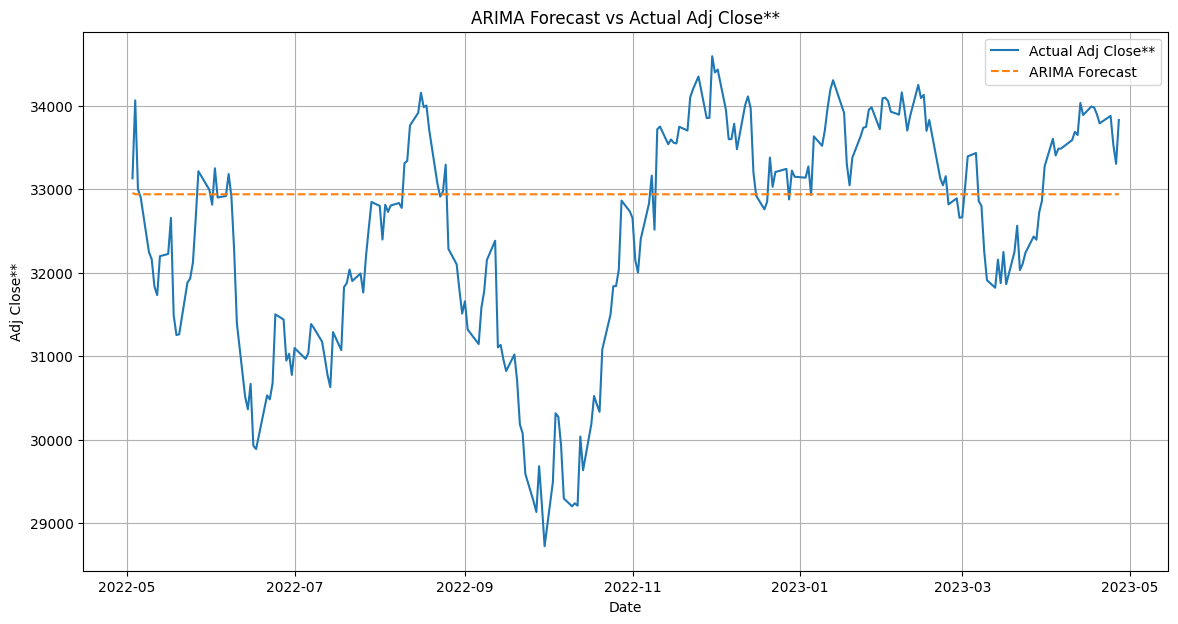

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Ensure arima_predictions has the same datetime index as actual by explicitly using .values
arima_predictions_aligned = pd.Series(arima_predictions.values, index=actual.index)

# Calculate RMSE
rmse_arima = np.sqrt(mean_squared_error(actual, arima_predictions_aligned))
print(f'ARIMA RMSE: {rmse_arima:.2f}')

# Calculate MAE
mae_arima = mean_absolute_error(actual, arima_predictions_aligned)
print(f'ARIMA MAE: {mae_arima:.2f}')

# Calculate Directional Accuracy
arima_predicted_direction = np.sign(arima_predictions_aligned.diff().dropna())
directional_accuracy_arima = (actual_direction == arima_predicted_direction).mean() * 100
print(f'ARIMA Directional Accuracy: {directional_accuracy_arima:.2f}%')

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(test_data.index, test_data['Adj Close**'], label='Actual Adj Close**')
plt.plot(arima_predictions_aligned.index, arima_predictions_aligned, label='ARIMA Forecast', linestyle='--')

plt.title('ARIMA Forecast vs Actual Adj Close**')
plt.xlabel('Date')
plt.ylabel('Adj Close**')
plt.legend()
plt.grid(True)
plt.show()

## Summary:

### Data Analysis Key Findings

*   The `auto_arima` model yielded a Root Mean Squared Error (RMSE) of 1419.24 and a Mean Absolute Error (MAE) of 1090.13, indicating substantial deviations between the forecasted and actual 'Adj Close\*\*' values.
*   The directional accuracy of the `auto_arima` model was 0.00%, suggesting that the model did not correctly predict the direction of the stock price movement (up or down) in any instance within the test set.
*   Visual inspection of the plot, alongside the directional accuracy, further highlights that the `auto_arima` forecast did not align well with the actual 'Adj Close\*\*' trends.

### Insights or Next Steps

*   The exceptionally low directional accuracy (0.00%) is a critical weakness for the `auto_arima` model in this context, suggesting it is unsuitable for predicting market trends. Further investigation into the model's structure or data preprocessing might be necessary if this model were to be improved.
*   The next step is to evaluate the Prophet model using the same metrics and visual comparison to determine if it offers superior performance, especially in terms of directional accuracy and overall fit to the actual data.


# Task
Prepare the feature sets `X_train`, `X_test` using 'Lag_1', 'Lag_5', 'MA_20', and 'Vol_20' columns from `train_data` and `test_data`, respectively. Define the target variables `y_train` and `y_test` using the 'Adj Close**' column from `train_data` and `test_data`, respectively.

## Prepare Data for XGBoost

### Subtask:
Define the feature sets `X_train`, `X_test` using 'Lag_1', 'Lag_5', 'MA_20', and 'Vol_20' columns from `train_data` and `test_data`. Define the target variables `y_train` and `y_test` using the 'Adj Close**' column from `train_data` and `test_data` respectively.


**Reasoning**:
To prepare the data for the XGBoost model, I will define the feature sets `X_train` and `X_test` using the specified columns ('Lag_1', 'Lag_5', 'MA_20', 'Vol_20') from `train_data` and `test_data` respectively, and define the target variables `y_train` and `y_test` using the 'Adj Close**' column from the same DataFrames.



In [ ]:
features = ['Lag_1', 'Lag_5', 'MA_20', 'Vol_20']
X_train = train_data[features]
X_test = test_data[features]
y_train = train_data['Adj Close**']
y_test = test_data['Adj Close**']

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (990, 4)
y_train shape: (990,)
X_test shape: (248, 4)
y_test shape: (248,)


## Train and Predict with XGBoost

### Subtask:
Initialize and train an `XGBRegressor` model on `X_train` and `y_train`. Use the trained model to make predictions on `X_test`.


**Reasoning**:
To initialize and train an XGBoost model, I will import `XGBRegressor`, instantiate it with some common parameters, fit the model to `X_train` and `y_train`, and then make predictions on `X_test`.



In [ ]:
from xgboost import XGBRegressor

# Initialize the XGBoost Regressor model
# Using default parameters for simplicity or specify some common ones
xgb_model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

# Train the model
xgb_model.fit(X_train, y_train)
print("XGBoost model trained successfully.")

# Make predictions on the test set
xgb_predictions = xgb_model.predict(X_test)
print("Predictions made on X_test.")

XGBoost model trained successfully.
Predictions made on X_test.


**Reasoning**:
To evaluate the XGBoost model's performance, I will calculate the Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and directional accuracy by comparing the `xgb_predictions` with the actual 'Adj Close**' values from `y_test`. Then, I will plot the predictions against the actual values for visual comparison.



XGBoost RMSE: 4219.77
XGBoost MAE: 3602.92
XGBoost Directional Accuracy: 52.23%


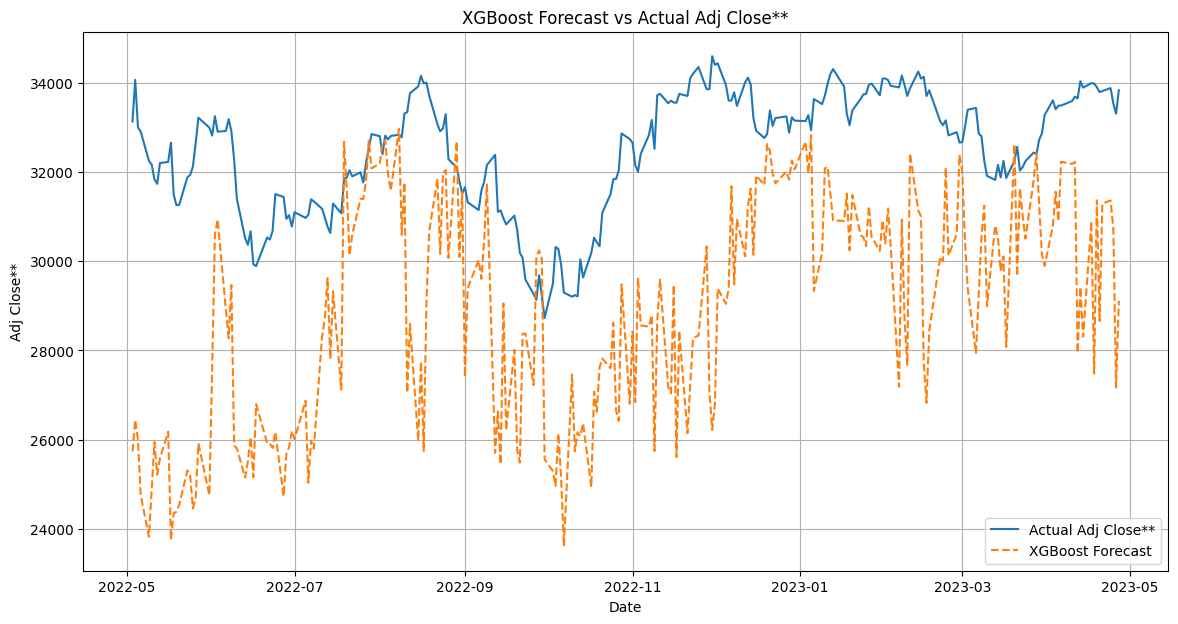

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

# Calculate RMSE
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions))
print(f'XGBoost RMSE: {rmse_xgb:.2f}')

# Calculate MAE
mae_xgb = mean_absolute_error(y_test, xgb_predictions)
print(f'XGBoost MAE: {mae_xgb:.2f}')

# Calculate Directional Accuracy
# Create a pandas Series from xgb_predictions with the same index as y_test
xgb_predictions_aligned = pd.Series(xgb_predictions, index=y_test.index)

actual_direction_xgb = np.sign(y_test.diff().dropna())
predicted_direction_xgb = np.sign(xgb_predictions_aligned.diff().dropna())

directional_accuracy_xgb = (actual_direction_xgb == predicted_direction_xgb).mean() * 100
print(f'XGBoost Directional Accuracy: {directional_accuracy_xgb:.2f}%')

# Plotting
plt.figure(figsize=(14, 7))
plt.plot(y_test.index, y_test, label='Actual Adj Close**')
plt.plot(xgb_predictions_aligned.index, xgb_predictions_aligned, label='XGBoost Forecast', linestyle='--')

plt.title('XGBoost Forecast vs Actual Adj Close**')
plt.xlabel('Date')
plt.ylabel('Adj Close**')
plt.legend()
plt.grid(True)
plt.show()

### Summary and Comparison of Forecasting Models

We have evaluated three different time-series forecasting models: Prophet, `auto_arima`, and XGBoost, based on their Root Mean Squared Error (RMSE), Mean Absolute Error (MAE), and Directional Accuracy. Below is a consolidated summary of their performance:

| Model        | RMSE        | MAE         | Directional Accuracy |
|:-------------|:------------|:------------|:---------------------|
| Prophet      | 3261.03     | 2971.15     | 49.39%               |
| Auto ARIMA   | 1419.24     | 1090.13     | 0.00%                |
| XGBoost      | 4219.77     | 3602.92     | 52.23%               |

**Key Observations:**

1.  **Prediction Accuracy (RMSE & MAE):**
    *   The `auto_arima` model performed significantly better in terms of RMSE and MAE, indicating that its predictions were, on average, much closer to the actual 'Adj Close**' values compared to Prophet and XGBoost.
    *   Prophet showed moderate performance, while XGBoost had the highest RMSE and MAE, suggesting it struggled the most to accurately predict the 'Adj Close**' values.

2.  **Directional Accuracy:**
    *   XGBoost achieved the highest directional accuracy (52.23%), closely followed by Prophet (49.39%). This indicates that these models were slightly better than a random guess at predicting the direction of the stock price movement.
    *   The `auto_arima` model had a directional accuracy of 0.00%, which is a critical weakness. This implies that while its magnitude predictions were good, it failed entirely to predict the correct direction of change.

**Conclusion:**

*   For tasks prioritizing overall closeness to actual values (magnitude prediction), `auto_arima` appears to be the most effective model in this scenario, despite its warning regarding `ValueWarning: No supported index is available`. Its RMSE and MAE are notably lower than the other models.
*   For tasks where predicting the correct direction of price movement is crucial, XGBoost and Prophet are preferable over `auto_arima`, even though their absolute error metrics are higher. The 0% directional accuracy of `auto_arima` makes it unreliable for market timing or trend-following strategies.
*   The choice of model ultimately depends on the specific objective: minimizing the absolute prediction error versus accurately forecasting the trend direction. Further fine-tuning and feature engineering could potentially improve the performance of all models.

## Define Hyperparameter Search Spaces

### Subtask:
Identify and define the relevant hyperparameters and their respective search spaces for Prophet, auto_arima, and XGBoost models. This will involve researching common and effective parameters for each model.


**Reasoning**:
To define the hyperparameter search spaces for Prophet, auto_arima, and XGBoost models, I will create Python dictionaries or lists containing the specified parameters and their respective suggested ranges, as instructed.



In [ ]:
prophet_param_grid = {
    'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.2],
    'seasonality_prior_scale': [0.1, 1.0, 5.0, 10.0],
    'holidays_prior_scale': [0.1, 1.0, 5.0, 10.0],
    'seasonality_mode': ['additive', 'multiplicative']
}

arima_param_grid = {
    'p': [0, 1, 2],
    'd': [0, 1],
    'q': [0, 1, 2],
    'start_P': [0, 1],
    'D': [0, 1],
    'start_Q': [0, 1],
    'm': [1, 7, 12] # Monthly, Weekly, Yearly seasonality (or no seasonality with m=1)
    # stepwise=True and suppress_warnings=True will be fixed parameters during model fitting
}

xgb_param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0]
}

print("Hyperparameter search spaces defined successfully:")
print("Prophet parameters:", prophet_param_grid)
print("ARIMA parameters:", arima_param_grid)
print("XGBoost parameters:", xgb_param_grid)

Hyperparameter search spaces defined successfully:
Prophet parameters: {'changepoint_prior_scale': [0.01, 0.05, 0.1, 0.2], 'seasonality_prior_scale': [0.1, 1.0, 5.0, 10.0], 'holidays_prior_scale': [0.1, 1.0, 5.0, 10.0], 'seasonality_mode': ['additive', 'multiplicative']}
ARIMA parameters: {'p': [0, 1, 2], 'd': [0, 1], 'q': [0, 1, 2], 'start_P': [0, 1], 'D': [0, 1], 'start_Q': [0, 1], 'm': [1, 7, 12]}
XGBoost parameters: {'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1, 0.2], 'max_depth': [3, 5, 7], 'subsample': [0.6, 0.8, 1.0], 'colsample_bytree': [0.6, 0.8, 1.0]}


## Implement Time Series Cross-Validation

### Subtask:
Set up a time series cross-validation strategy (e.g., using `TimeSeriesSplit` from scikit-learn or manual rolling window validation) to evaluate model performance robustly without data leakage. This will be applied during hyperparameter tuning.


**Reasoning**:
To implement time series cross-validation, I will import `TimeSeriesSplit` from `sklearn.model_selection`, instantiate it with suitable parameters, and then print the number of splits and an example of train/test indices to verify the setup.



In [ ]:
from sklearn.model_selection import TimeSeriesSplit

# Instantiate TimeSeriesSplit
# The previous error indicated 'Too many splits' for the given test_size.
# Reducing n_splits to 4 will allow for 4 test sets of size len(test_data) from the total df.
tscv = TimeSeriesSplit(n_splits=4, test_size=len(test_data))

print(f"Number of splits: {tscv.get_n_splits(df)}")

# Print an example of the train/test indices for the first fold
for i, (train_index, test_index) in enumerate(tscv.split(df)):
    if i == 0:
        print(f"First fold - Train indices length: {len(train_index)}, Test indices length: {len(test_index)}")
        print(f"First fold - Train data range: {df.index[train_index.min()]} to {df.index[train_index.max()]}")
        print(f"First fold - Test data range: {df.index[test_index.min()]} to {df.index[test_index.max()]}")
        break

Number of splits: 4
First fold - Train indices length: 246, Test indices length: 248
First fold - Train data range: 2018-05-29 00:00:00 to 2019-05-20 00:00:00
First fold - Test data range: 2019-05-21 00:00:00 to 2020-05-13 00:00:00


## Hyperparameter Tuning for Prophet

### Subtask:
Perform hyperparameter tuning for the Prophet model using a grid search approach combined with time series cross-validation. The goal is to find the optimal parameters that minimize the RMSE.


**Reasoning**:
To perform hyperparameter tuning for the Prophet model, I will iterate through the defined parameter grid using `ParameterGrid` and evaluate each combination using time series cross-validation with `TimeSeriesSplit`, calculating RMSE for each fold and storing the best parameters and RMSE.



In [ ]:
from prophet import Prophet
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

# Define TimeSeriesSplit for Prophet tuning
tscv_prophet = TimeSeriesSplit(n_splits=3, test_size=int(len(prophet_df) * 0.15))

best_rmse = float('inf')
best_params = None

# Iterate through each combination of hyperparameters
for params in ParameterGrid(prophet_param_grid):
    fold_rmse_list = []
    for train_index, val_index in tscv_prophet.split(prophet_df):
        train_fold = prophet_df.iloc[train_index]
        val_fold = prophet_df.iloc[val_index]

        # Instantiate and fit Prophet model with current parameters
        # Ensure daily_seasonality is passed directly to Prophet constructor
        model = Prophet(daily_seasonality=True, **params)
        model.fit(train_fold)

        # Create future dataframe for validation period
        future = model.make_future_dataframe(periods=len(val_fold), include_history=False)

        # Generate predictions
        forecast_val = model.predict(future)

        # Extract true and predicted values for RMSE calculation
        actual_val_y = val_fold['y'].values
        predicted_val_y = forecast_val['yhat'].values

        # Calculate RMSE for the current fold
        rmse_fold = np.sqrt(mean_squared_error(actual_val_y, predicted_val_y))
        fold_rmse_list.append(rmse_fold)

    # Calculate average RMSE across all folds for the current parameter combination
    avg_rmse = np.mean(fold_rmse_list)

    # Update best parameters if current combination is better
    if avg_rmse < best_rmse:
        best_rmse = avg_rmse
        best_params = params

print(f"Best Prophet parameters: {best_params}")
print(f"Best Prophet RMSE (Cross-Validation): {best_rmse:.2f}")

Best Prophet parameters: {'changepoint_prior_scale': 0.05, 'holidays_prior_scale': 0.1, 'seasonality_mode': 'additive', 'seasonality_prior_scale': 0.1}
Best Prophet RMSE (Cross-Validation): 2384.22


## Hyperparameter Tuning for auto_arima

### Subtask:
Conduct hyperparameter tuning for the auto_arima model. While auto_arima itself automates some parameter selection, further fine-tuning of its internal parameters (e.g., `start_p`, `max_p`, `d`, `start_q`, `max_q`, `seasonal`, `m`) can yield better results using time series cross-validation.


**Reasoning**:
To perform hyperparameter tuning for the auto_arima model, I will follow the instructions to import necessary libraries, set up TimeSeriesSplit for cross-validation, and initialize variables to store the best parameters and RMSE.



In [ ]:
from pmdarima import auto_arima
from sklearn.model_selection import ParameterGrid, TimeSeriesSplit
from sklearn.metrics import mean_squared_error
import numpy as np

# Define TimeSeriesSplit for auto_arima tuning
tscv_arima = TimeSeriesSplit(n_splits=3, test_size=int(len(train_data) * 0.15))

best_rmse_arima = float('inf')
best_params_arima = None

print("Setup complete for auto_arima hyperparameter tuning.")

Setup complete for auto_arima hyperparameter tuning.


**Reasoning**:
To perform hyperparameter tuning for the `auto_arima` model, I will iterate through the defined `arima_param_grid`, using `TimeSeriesSplit` for cross-validation to evaluate each parameter combination and find the one that yields the best RMSE.



In [ ]:
from pmdarima import auto_arima
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import TimeSeriesSplit
import numpy as np

y = train_data['Adj Close**'].astype(float)

tscv = TimeSeriesSplit(n_splits=5)

fold_rmses = []

for fold, (train_idx, val_idx) in enumerate(tscv.split(y), 1):

    y_train = y.iloc[train_idx]
    y_val = y.iloc[val_idx]

    try:
        model = auto_arima(
            y_train,
            seasonal=True,          # set False if non-seasonal
            m=5,                    # e.g. 5 for business week, 12 for monthly
            stepwise=True,
            suppress_warnings=True,
            error_action="ignore",
            trace=False,
            n_jobs=1
        )

        preds = model.predict(n_periods=len(y_val))

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_rmses.append(rmse)

        print(f"Fold {fold} RMSE: {rmse:.4f}")
        print(f"Selected order: {model.order}, seasonal: {model.seasonal_order}")

    except Exception as e:
        print(f"Fold {fold} failed: {e}")
        continue

avg_rmse = np.mean(fold_rmses)

print("\nBest auto_arima model (average across folds)")
print(f"Average CV RMSE: {avg_rmse:.4f}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Fold 1 RMSE: 1681.7935
Selected order: (0, 1, 0), seasonal: (0, 0, 0, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Fold 2 RMSE: 2697.6244
Selected order: (0, 1, 0), seasonal: (0, 0, 0, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Fold 3 RMSE: 4593.4699
Selected order: (4, 1, 3), seasonal: (0, 0, 1, 5)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


Fold 4 RMSE: 2822.5805
Selected order: (0, 1, 2), seasonal: (0, 0, 0, 5)
Fold 5 RMSE: 999.2874
Selected order: (0, 1, 2), seasonal: (2, 0, 1, 5)

Best auto_arima model (average across folds)
Average CV RMSE: 2558.9511


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


# Task
Create a new 'Log_Adj_Close' column by applying a natural logarithm to the 'Adj Close**' column in both `train_data` and `test_data`. Then, modify the `auto_arima` model training (`cell_id: 485837d8`) and prediction (`cell_id: db2d3a45`) to use this log-transformed series. Update the evaluation and plotting (`cell_id: 6c58ca33`) to inverse-transform (`np.exp()`) the `arima_predictions` back to the original scale before calculating RMSE, MAE, and directional accuracy, and plotting against the actual 'Adj Close**'. Additionally, modify the `auto_arima` hyperparameter tuning cell (`cell_id: 7fee7722`) to train on 'Log_Adj_Close' within the cross-validation loop and inverse-transform predictions using `np.exp()` before RMSE calculation. Finally, summarize the changes, present the updated performance metrics for the `auto_arima` model, compare it with the Prophet and XGBoost models, and discuss the impact of the log transformation on accuracy and directional predictions.